# Octet Example: One-to-One Induced Fit with Linked Rmax

This notebook imports the Octet example folder, performs baseline/association alignment, dissociation alignment with `npoints=1`, subtracts the `H1` reference sensor, selects the first eight curve rows, and fits a one-to-one induced-fit model with linked Rmax.

In pyKingenie surface-fitting APIs, the fitted response amplitude is named `Smax`; here `shared_smax=True` links that amplitude across curves with the same `Smax_ID`.

In [1]:
from pathlib import Path
import os
import sys
import tempfile
import numpy as np

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / "src" / "pykingenie").exists() else cwd.parent

for path in [repo_root / "src", repo_root / "notebooks"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "pykingenie-matplotlib"))

from pykingenie import OctetExperiment, KineticsAnalyzer
from pykingenie.utils.plotting import plot_association_dissociation, plot_traces
from pykingenie.utils.palettes import VIRIDIS

try:
    from notebook_helpers import show_plotly_static as _show_plotly_static
except ImportError:
    _show_plotly_static = None

def show_plotly_static(fig, **kwargs):
    if _show_plotly_static is None:
        return fig
    try:
        return _show_plotly_static(fig, **kwargs)
    except Exception as exc:
        print(f"Static rendering skipped: {exc}")
        return fig

def show_experiment_traces(experiment, title, width=1000, height=650):
    colors = [VIRIDIS[int(i)] for i in np.linspace(0, len(VIRIDIS) - 1, len(experiment.sensor_names))]
    fig = plot_traces(
        xs=experiment.xs,
        ys=experiment.ys,
        legends=experiment.sensor_names,
        colors=colors,
        show=[True] * len(experiment.sensor_names),
        marker_size=1,
        line_width=2,
    )
    fig.update_layout(
        title={"text": title, "font": {"size": 26}},
        xaxis_title="Time (s)",
        yaxis_title="Response",
        font={"size": 16},
    )
    show_plotly_static(fig, width=width, height=height)
    return fig

## Import Octet Example Folder

In [2]:
example_folder = repo_root / "test_files"

frd_files = [
    example_folder / file_name
    for file_name in os.listdir(example_folder)
    if file_name.endswith(".frd") and file_name.startswith("230309")
]
frd_files = sorted(frd_files)

bli = OctetExperiment("octet_example")
bli.read_sensor_data([str(file_path) for file_path in frd_files])

print(f"Imported {len(frd_files)} Octet .frd files")
print(bli.sensor_names)

Imported 8 Octet .frd files
['A1', 'B1', 'C1', 'D1', 'E1', 'F1', 'G1', 'H1']


## Before Baseline Alignment

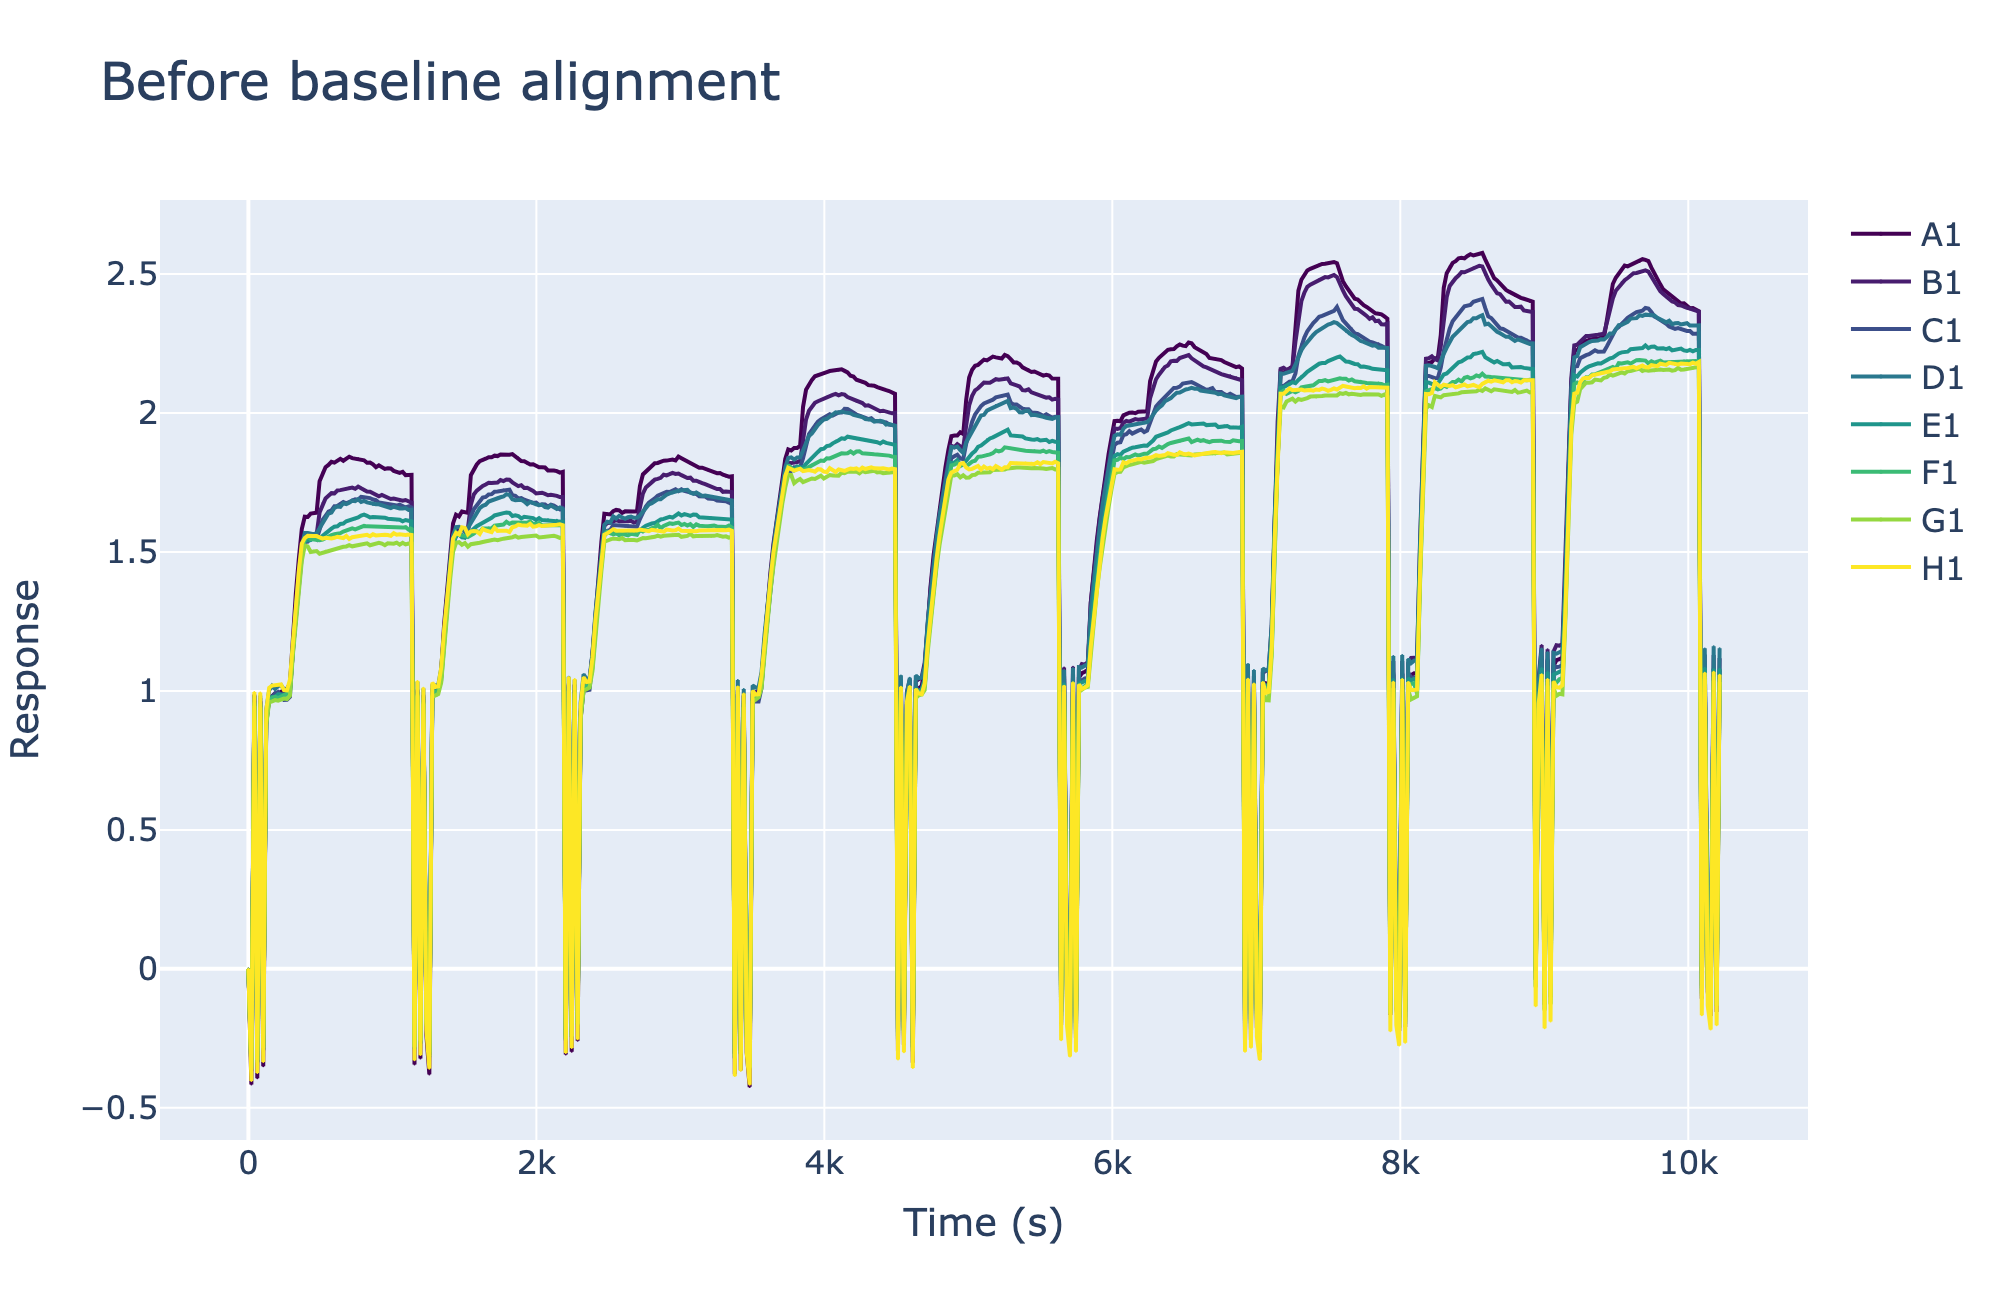

In [3]:
fig_before_baseline_alignment = show_experiment_traces(
    bli,
    "Before baseline alignment",
)

## Before Dissociation Alignment

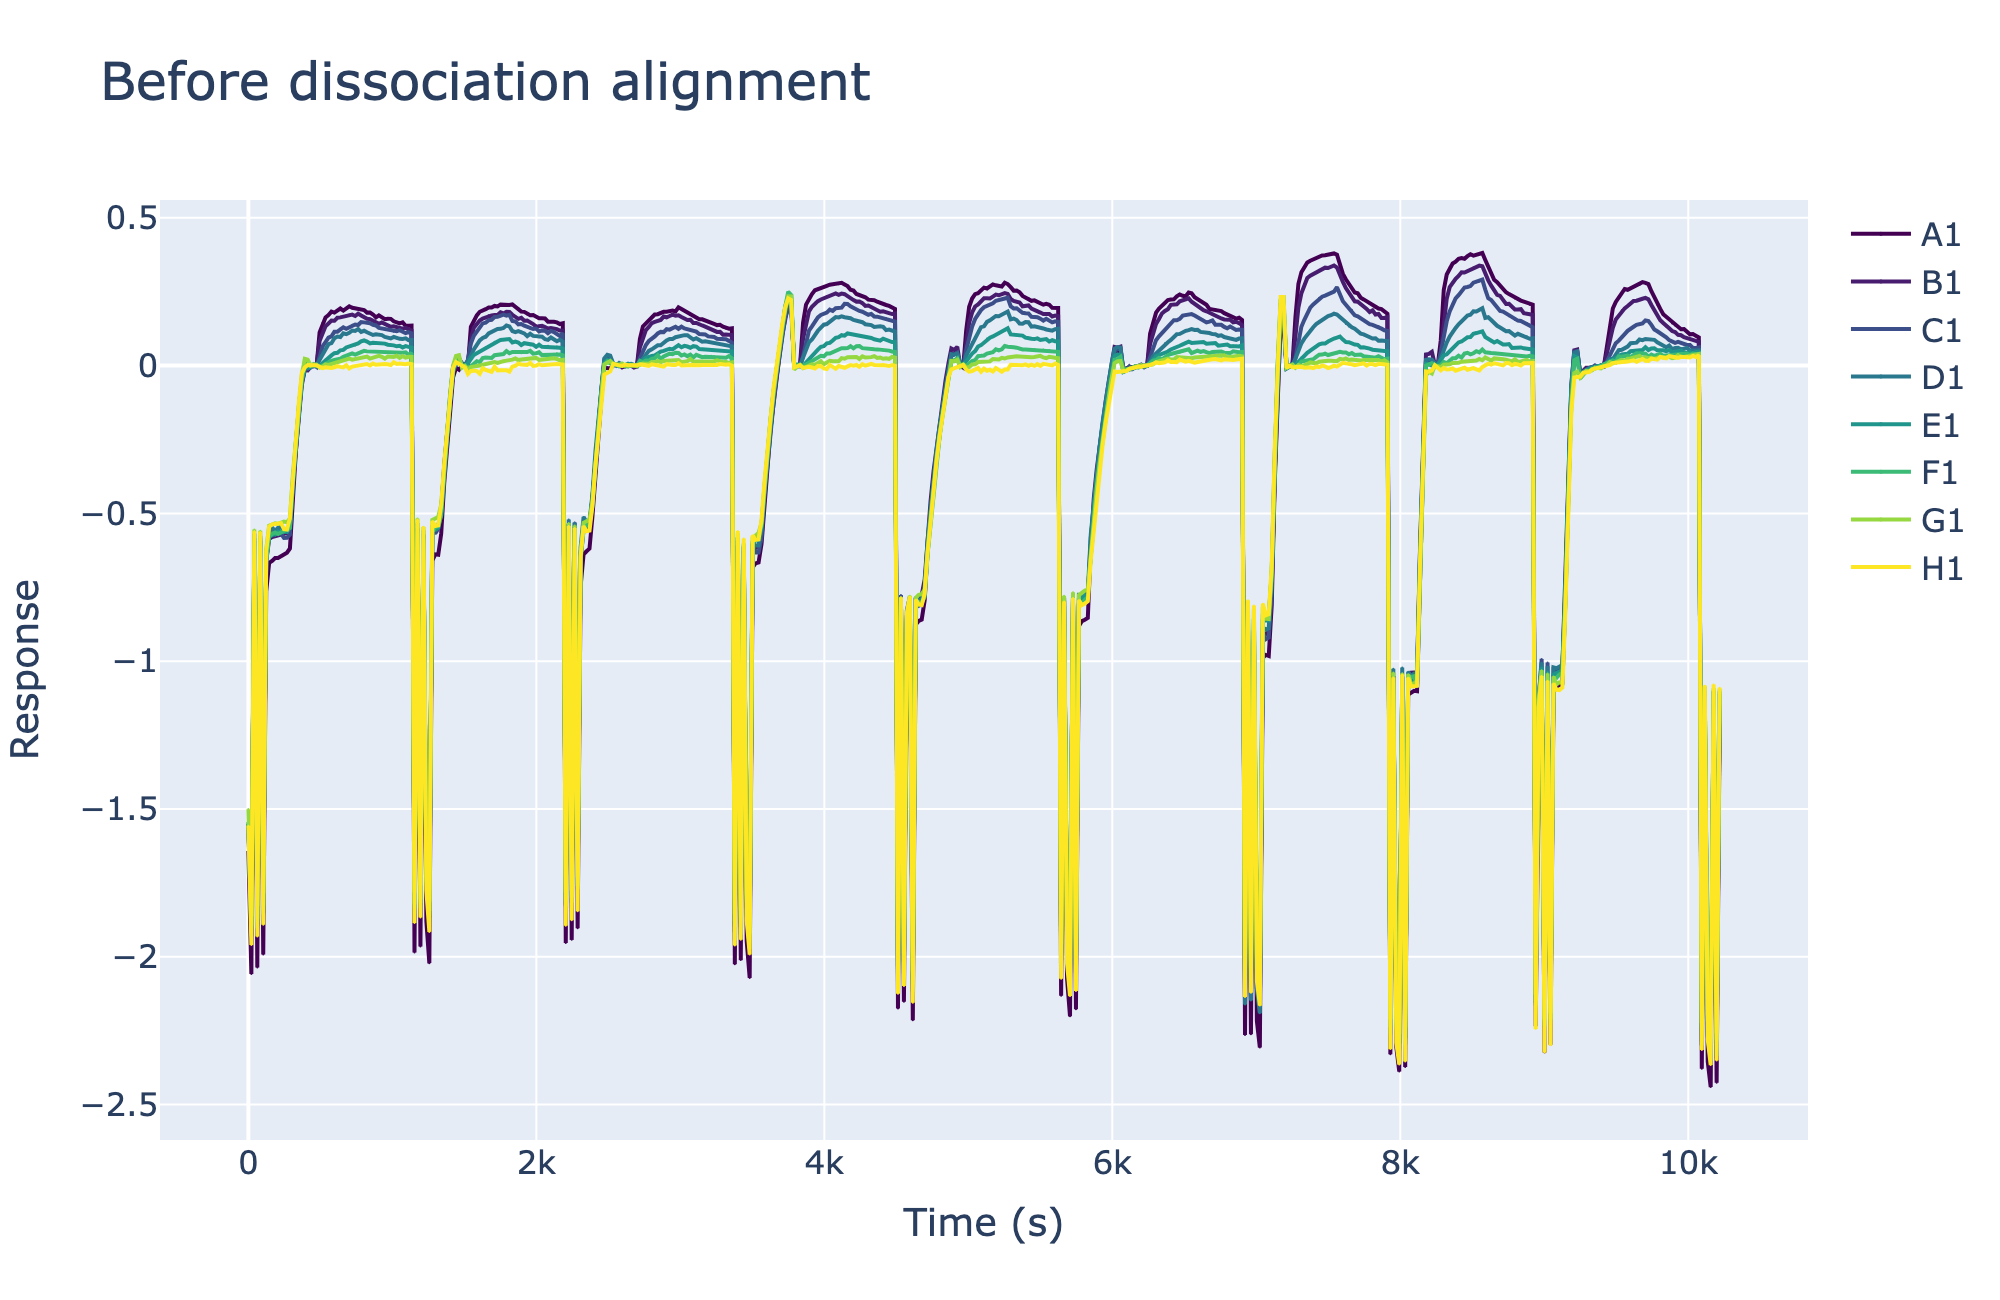

In [4]:
bli.align_association(bli.sensor_names, npoints=1)

fig_before_dissociation_alignment = show_experiment_traces(
    bli,
    "Before dissociation alignment",
)

## Before Baseline Subtraction

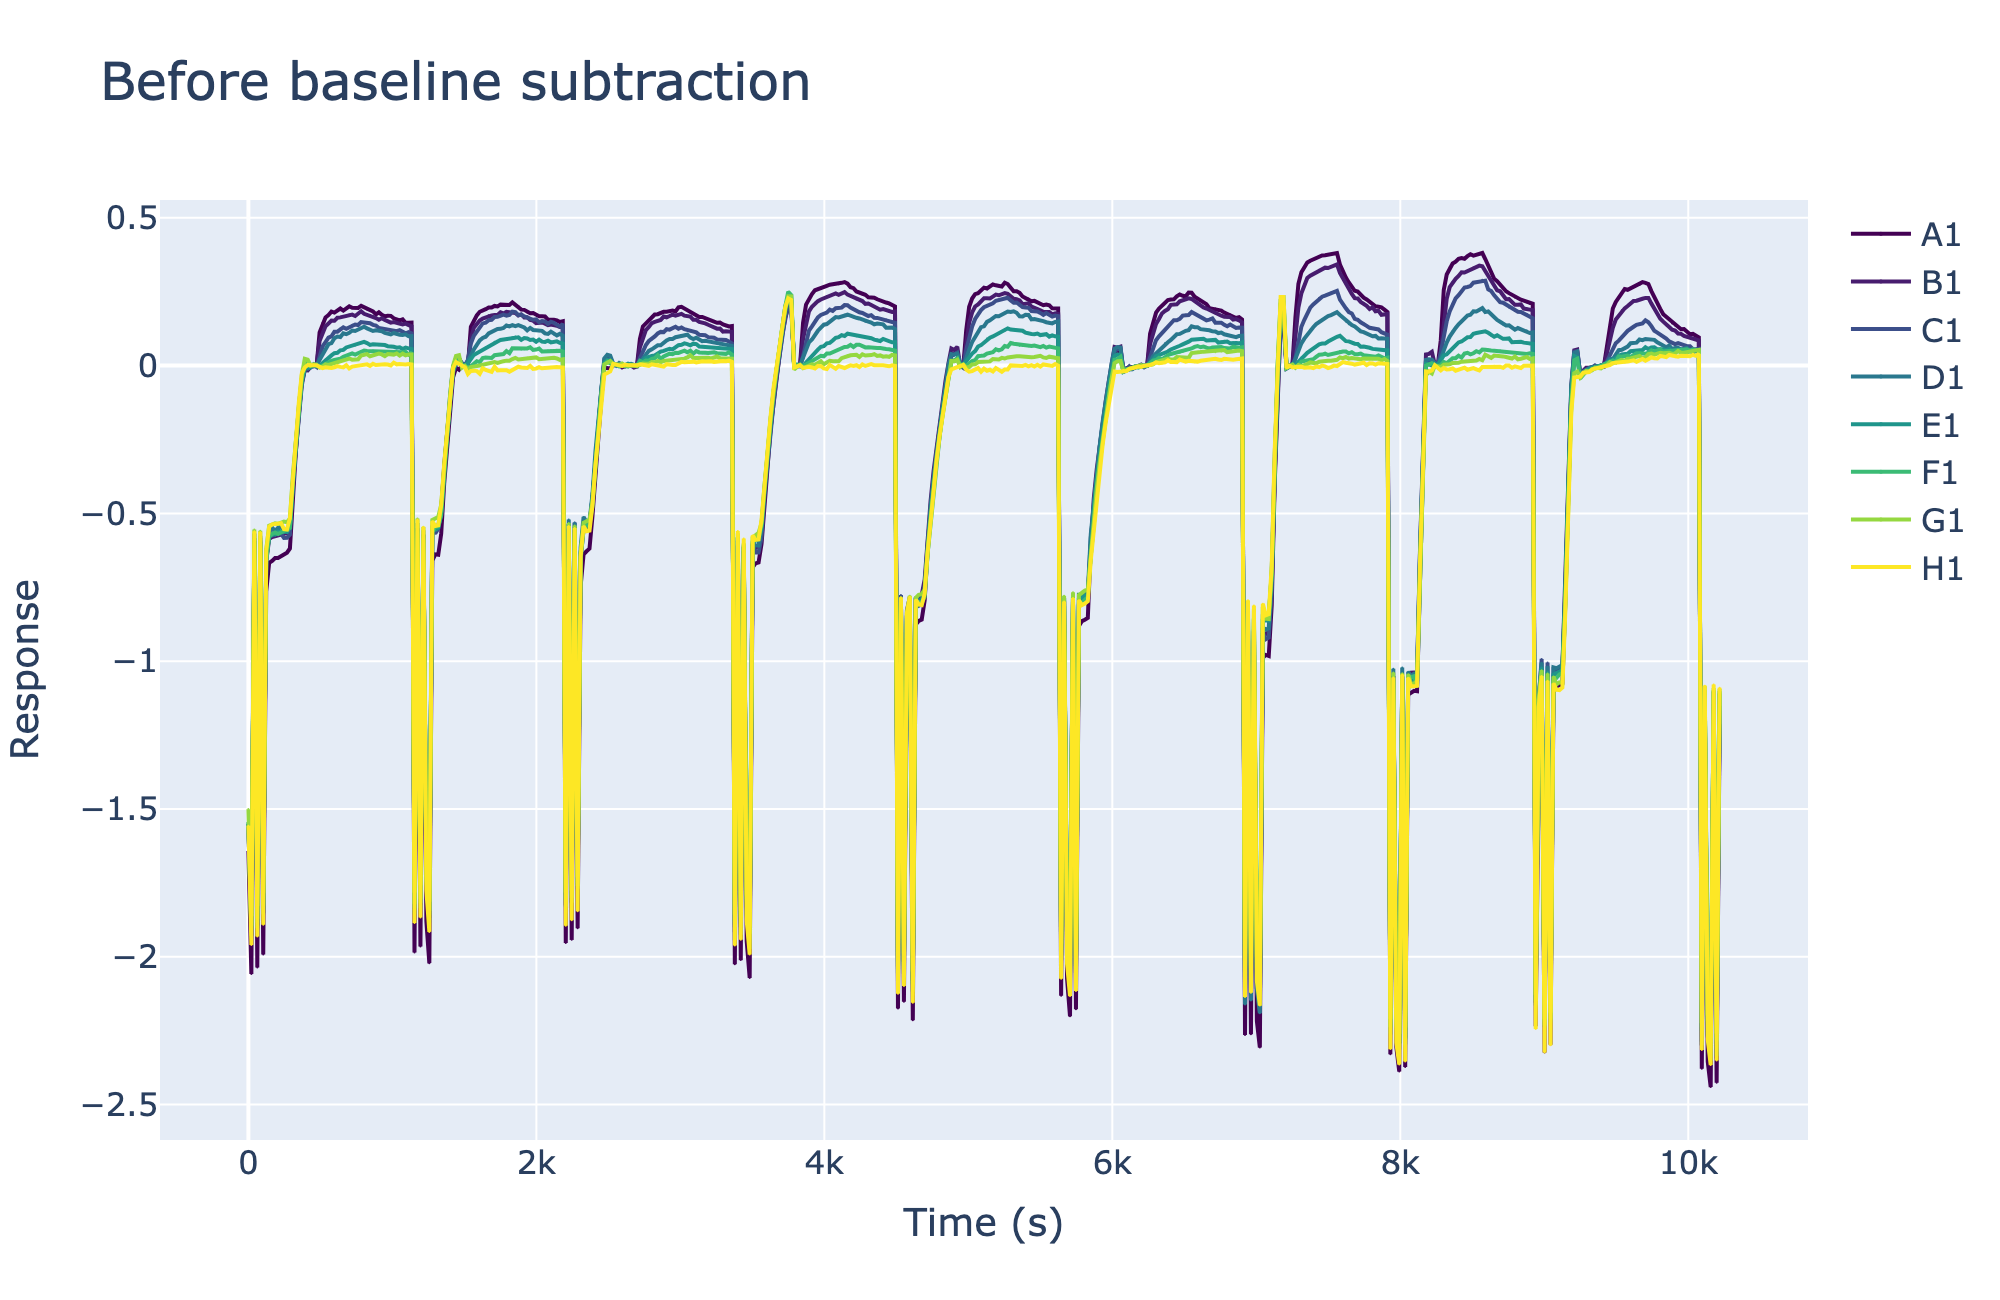

In [5]:
bli.align_dissociation(bli.sensor_names, npoints=1)

fig_before_baseline_subtraction = show_experiment_traces(
    bli,
    "Before baseline subtraction",
)

## After Baseline Subtraction

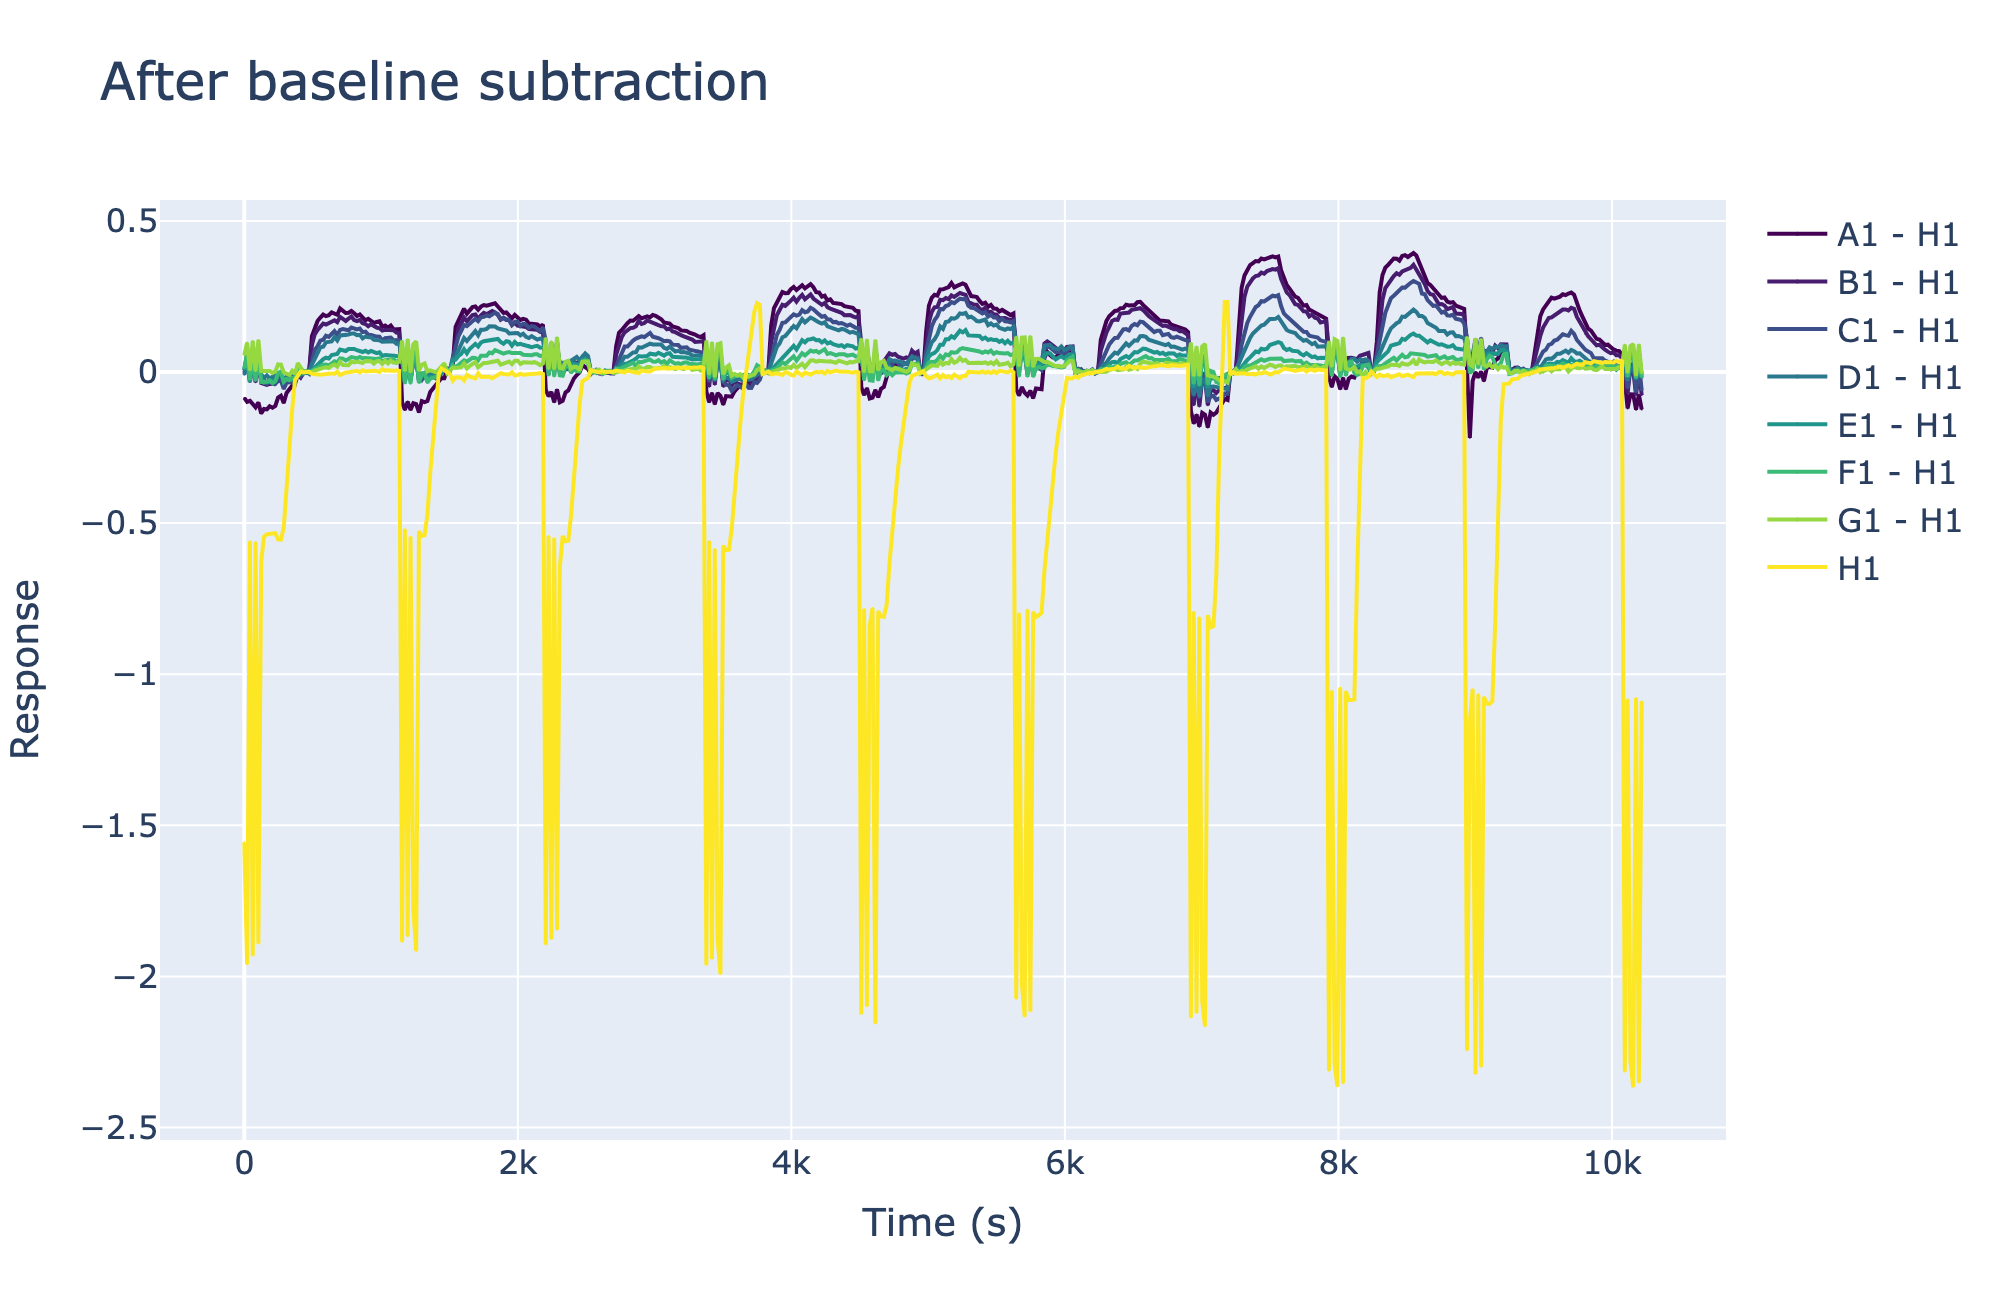

['A1 - H1', 'B1 - H1', 'C1 - H1', 'D1 - H1', 'E1 - H1', 'F1 - H1', 'G1 - H1', 'H1']


In [6]:
reference_sensor = "H1"
sensors_to_subtract = [sensor for sensor in bli.sensor_names if sensor != reference_sensor]
bli.subtraction(sensors_to_subtract, reference_sensor)

fig_after_baseline_subtraction = show_experiment_traces(
    bli,
    "After baseline subtraction",
)

print(bli.sensor_names)

## Select First Eight Curves

In [7]:
pyKinetics = KineticsAnalyzer()
pyKinetics.add_experiment(bli, "octet_example")
pyKinetics.merge_ligand_conc_df()

selected_curves = pyKinetics.combined_ligand_conc_df.iloc[:8].copy()
selected_curves

,Sensor,[Analyte] (μM),SampleID,Select,Smax_ID,Analyte_location,Loading_location,Replicate
0,A1 - H1,0.1300,wt - imd,True,0,5,12,1
1,B1 - H1,0.0692,wt - imd,True,0,5,12,1
2,C1 - H1,0.0299,wt - imd,True,0,5,12,1
3,D1 - H1,0.0130,wt - imd,True,0,5,12,1
4,E1 - H1,0.0056,wt - imd,True,0,5,12,1
5,F1 - H1,0.0024,wt - imd,True,0,5,12,1
6,G1 - H1,0.0010,wt - imd,True,0,5,12,1
7,H1,0.0000,wt - imd,True,0,5,12,1


The first eight rows include the `H1` reference at 0 uM. The fitting setup keeps only positive analyte concentrations, so seven subtracted curves are fit.

In [8]:
pyKinetics.init_fittings()
messages = pyKinetics.generate_fittings(selected_curves)

print("\n".join(messages))
print(pyKinetics.fittings_names)

Creating a new fitting object for sample: wt - imd
['wt - imd']


## Fit One-to-One Induced Fit with Linked Rmax

In [9]:
# The induced-fit optimizer requires a Kd seed, but this avoids running a steady-state fit.
for fitter in pyKinetics.fittings.values():
    fitter.Kd_ss = float(np.median(fitter.lig_conc_lst))
    fitter.Smax_upper_bound_factor = 1e2

pyKinetics.submit_kinetics_fitting(
    fitting_model="one_to_one_if",
    fitting_region="association_dissociation",
    shared_smax=True,
)

pyKinetics.get_fitting_results()
pyKinetics.fit_params_kinetics_all

,k_on [1/(s*µM)],k_off [1/s],k_c [1/s],k_rev [1/s],Smax,Name
0,0.33095,0.007138,0.002332,0.001087,0.408169,wt - imd


## Plot Fit

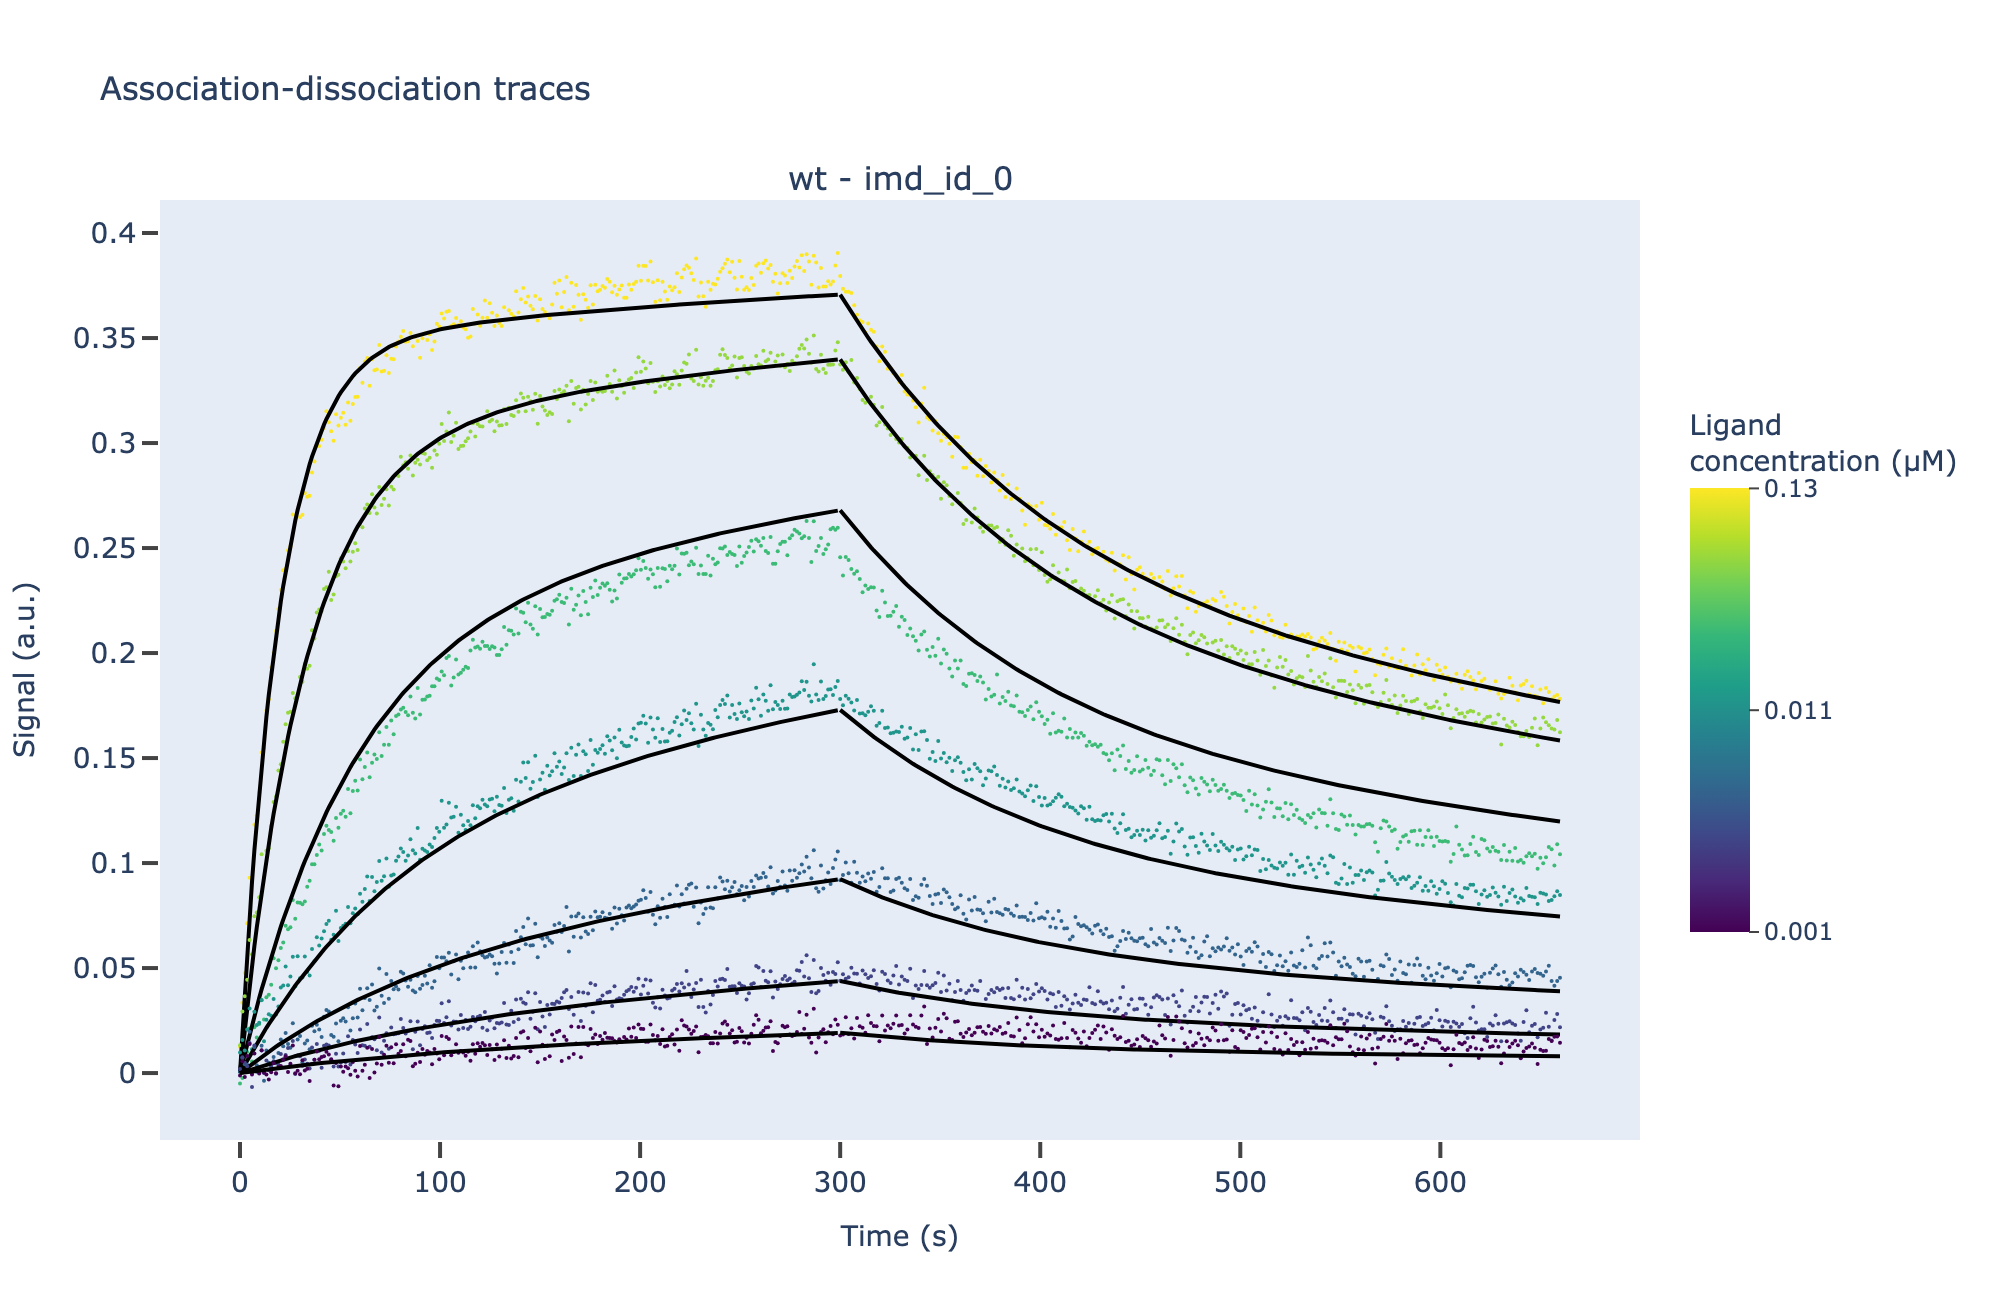

In [10]:
fig_fit = plot_association_dissociation(
    pyKinetics,
    split_by_smax_id=True,
    plot_width=12,
    plot_height=8,
    marker_size=2,
    line_width=2,
)
show_plotly_static(fig_fit, width=1000, height=650)